In [1]:
from learn_to_infer import Worker
from task import probabilistic_task
import pandas as pd
import torch
import numpy as np
from matplotlib import pyplot as plt

import matplotlib as mpl
mpl.rcParams['pdf.fonttype'] = 42
mpl.rcParams['ps.fonttype'] = 42


In [ ]:
from tensorboard.backend.event_processing import event_accumulator
import pandas as pd
import os
import glob

nb_trials_train = 500
nb_tasks_train = 10

all_losses = []

for id_agent in range(30):
    event_dir = f"results/source/trainings_fullRNN"
    agent_pattern = f"WP_GRU_agent{id_agent}_init_xavier_optim_Adam_episodeNbMax_50000_numUnits_32_trainWithEmission_False_trainInCatTaskFromScratch_False"
    possible_event_dir = os.path.join(event_dir, agent_pattern)
    # Find event file dynamically in that folder
    event_files = glob.glob(os.path.join(possible_event_dir, "events.out.tfevents.*yggdrasil*"))
    if not event_files:
        print(f"No event files found for agent {id_agent}")
        assert False
    event_file = event_files[np.argmax([int(e.split('.')[3]) for e in event_files])]
    ea = event_accumulator.EventAccumulator(
        event_file,
        size_guidance={event_accumulator.SCALARS: 0}
    )
    ea.Reload()
    loss_events = ea.Scalars('Train/NegLogLikelihood_Loss')

    times = [e.wall_time for e in loss_events]
    steps = [e.step for e in loss_events]
    values = [e.value for e in loss_events]

    loss_df = pd.DataFrame({
        'wall_time': times,
        'step': steps,
        'loss': values
    })
    loss_df["agent_id"] = id_agent  # Add a column to track the agent

    all_losses.append(loss_df)

loss_df = pd.concat(all_losses, ignore_index=True)
loss_df['loss'] = loss_df['loss'] / nb_tasks_train # the division by nb_trials_train is done in learn_to_infer.py

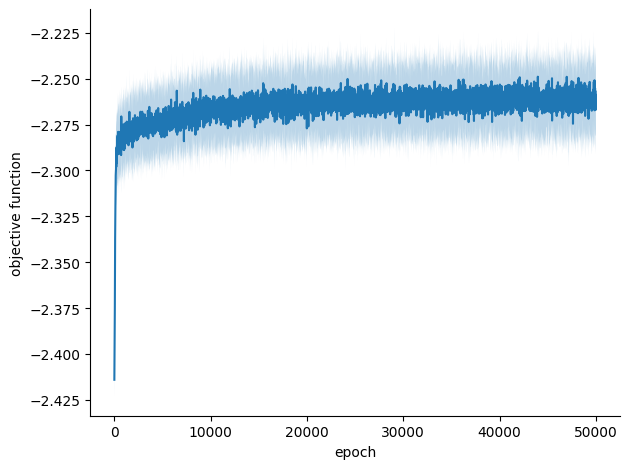

In [ ]:
import matplotlib.pyplot as plt

loss_stats = loss_df.groupby('step').loss.agg(['mean', 'std'])
fig, ax = plt.subplots()
ax.plot(loss_stats.index, -loss_stats['mean'])
ax.fill_between(loss_stats.index, 
                -loss_stats['mean'] - loss_stats['std'], 
                -loss_stats['mean'] + loss_stats['std'],
                alpha=0.3)
#ax.set_yticks([-1200, -1150, -1100])
ax.spines['right'].set_visible(False)
ax.spines['top'].set_visible(False)
ax.set_xlabel('epoch')
ax.set_ylabel('objective function')
plt.tight_layout()
plt.savefig('figures/loss_epoch_mars2026.pdf')
plt.show()

In [9]:
# time estimation
from tqdm import tqdm
all_times = []

for index in tqdm(range(30)):
    self = Worker(
        probabilistic_task(),
        "results/source/saved_models_5cues",
        "WP_GRU_agent{0}".format(index),
        w_emission=True,
        train_w_emission=False,
        train_in_cat_task_from_scratch=False,
        entropy_reg=None   
    )
    self.load_model()

    # learn task A
    import time
    np.random.seed(index)
    torch.manual_seed(index)
    self.env.generate_test_task(num_tasks=100, num_trials=500)
    start_time = time.time()
    result = self.evaluate()
    end_time = time.time()
    all_times.append(end_time - start_time)

print(f"Time taken: mean {np.mean(all_times)} seconds, std {np.std(all_times)} seconds")

  0%|          | 0/30 [00:00<?, ?it/s]

loaded the emission model with 50000 iterations
loading model results/source/saved_models_5cues/WP_GRU_agent0_init_xavier_optim_Adam_episodeNbMax_50000_numUnits_32_trainWithEmission_False_trainInCatTaskFromScratch_False/model-50000.pth
loaded W_output_association
key W_output_emission not found in state_dict
loaded gru_association.weight_ih_l0
loaded gru_association.weight_hh_l0
loaded gru_association.bias_ih_l0
loaded gru_association.bias_hh_l0
key gru_emission.weight_ih_l0 not found in state_dict
key gru_emission.weight_hh_l0 not found in state_dict
key gru_emission.bias_ih_l0 not found in state_dict
key gru_emission.bias_hh_l0 not found in state_dict
loaded the association model
loading model results/source/saved_models_5cues/WP_GRU_agent0_init_xavier_optim_Adam_episodeNbMax_50000_numUnits_32_trainWithEmission_False_trainInCatTaskFromScratch_False/model-50000.pth
loaded W_output_association
key W_output_emission not found in state_dict
loaded gru_association.weight_ih_l0
loaded gru_

  3%|▎         | 1/30 [00:02<01:19,  2.73s/it]

loaded the emission model with 50000 iterations
loading model results/source/saved_models_5cues/WP_GRU_agent1_init_xavier_optim_Adam_episodeNbMax_50000_numUnits_32_trainWithEmission_False_trainInCatTaskFromScratch_False/model-50000.pth
loaded W_output_association
key W_output_emission not found in state_dict
loaded gru_association.weight_ih_l0
loaded gru_association.weight_hh_l0
loaded gru_association.bias_ih_l0
loaded gru_association.bias_hh_l0
key gru_emission.weight_ih_l0 not found in state_dict
key gru_emission.weight_hh_l0 not found in state_dict
key gru_emission.bias_ih_l0 not found in state_dict
key gru_emission.bias_hh_l0 not found in state_dict
loaded the association model
loading model results/source/saved_models_5cues/WP_GRU_agent1_init_xavier_optim_Adam_episodeNbMax_50000_numUnits_32_trainWithEmission_False_trainInCatTaskFromScratch_False/model-50000.pth
loaded W_output_association
key W_output_emission not found in state_dict
loaded gru_association.weight_ih_l0
loaded gru_

  7%|▋         | 2/30 [00:05<01:16,  2.72s/it]

...

loaded the emission model with 50000 iterations
loading model results/source/saved_models_5cues/WP_GRU_agent28_init_xavier_optim_Adam_episodeNbMax_50000_numUnits_32_trainWithEmission_False_trainInCatTaskFromScratch_False/model-50000.pth
loaded W_output_association
key W_output_emission not found in state_dict
loaded gru_association.weight_ih_l0
loaded gru_association.weight_hh_l0
loaded gru_association.bias_ih_l0
loaded gru_association.bias_hh_l0
key gru_emission.weight_ih_l0 not found in state_dict
key gru_emission.weight_hh_l0 not found in state_dict
key gru_emission.bias_ih_l0 not found in state_dict
key gru_emission.bias_hh_l0 not found in state_dict
loaded the association model
loading model results/source/saved_models_5cues/WP_GRU_agent28_init_xavier_optim_Adam_episodeNbMax_50000_numUnits_32_trainWithEmission_False_trainInCatTaskFromScratch_False/model-50000.pth
loaded W_output_association
key W_output_emission not found in state_dict
loaded gru_association.weight_ih_l0
loaded gr

 97%|█████████▋| 29/30 [01:18<00:02,  2.68s/it]

loaded the emission model with 50000 iterations
loading model results/source/saved_models_5cues/WP_GRU_agent29_init_xavier_optim_Adam_episodeNbMax_50000_numUnits_32_trainWithEmission_False_trainInCatTaskFromScratch_False/model-50000.pth
loaded W_output_association
key W_output_emission not found in state_dict
loaded gru_association.weight_ih_l0
loaded gru_association.weight_hh_l0
loaded gru_association.bias_ih_l0
loaded gru_association.bias_hh_l0
key gru_emission.weight_ih_l0 not found in state_dict
key gru_emission.weight_hh_l0 not found in state_dict
key gru_emission.bias_ih_l0 not found in state_dict
key gru_emission.bias_hh_l0 not found in state_dict
loaded the association model
loading model results/source/saved_models_5cues/WP_GRU_agent29_init_xavier_optim_Adam_episodeNbMax_50000_numUnits_32_trainWithEmission_False_trainInCatTaskFromScratch_False/model-50000.pth
loaded W_output_association
key W_output_emission not found in state_dict
loaded gru_association.weight_ih_l0
loaded gr

100%|██████████| 30/30 [01:20<00:00,  2.69s/it]

Time taken: mean 1.7106035947799683 seconds, std 0.05068332009842428 seconds


In [ ]:
index = 18

self = Worker(
    probabilistic_task(),
    "results/source/saved_models_fromScratchFalse",
    "WP_GRU_agent{0}".format(index),
    w_emission=False,
    train_w_emission=False,
    train_in_cat_task_from_scratch=False,
    entropy_reg=None    
)

self.load_model()

loading model results/source/saved_models_fromScratchFalse/WP_GRU_agent18_init_xavier_optim_Adam_episodeNbMax_50000_numUnits_32_trainWithEmission_False_trainInCatTaskFromScratch_False/model-50000.pth
loaded W_output_association
loaded gru_association.weight_ih_l0
loaded gru_association.weight_hh_l0
loaded gru_association.bias_ih_l0
loaded gru_association.bias_hh_l0


In [ ]:
# learn task A
np.random.seed(0)
self.env.generate_test_task(num_tasks=10, num_trials=500, num_steps=5, probas=None, variable_length=False, tau=0.01)
result = self.evaluate()

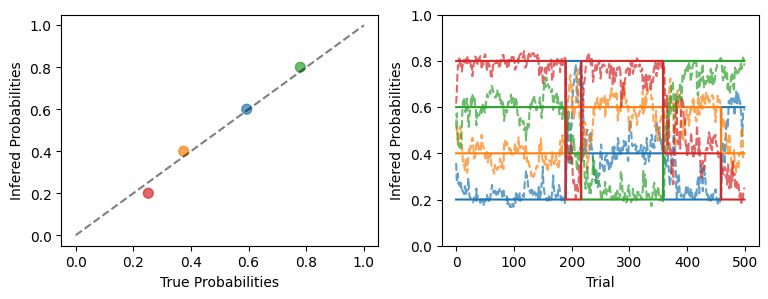

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(9, 3))
plt.subplot(1, 2, 1)
plt.scatter(result['probas_association'][0, -1], result['true_association_probas'][0, -1], alpha=0.7, color=["#1f77b4", "#ff7f0e", "#2ca02c", "#d62728"], s=50)
plt.plot([0, 1], [0, 1], 'k--', alpha=0.5, label='x=y')
plt.ylabel('Infered Probabilities')
plt.xlabel('True Probabilities')
plt.subplot(1, 2, 2)
for i in range(4):
    plt.plot(result['true_association_probas'][0, :, i], color=["#1f77b4", "#ff7f0e", "#2ca02c", "#d62728"][i])
    plt.plot(result['probas_association'][0, :, i], linestyle='--', alpha=0.7, color=["#1f77b4", "#ff7f0e", "#2ca02c", "#d62728"][i])
plt.ylabel('Infered Probabilities')
plt.xlabel('Trial')
plt.gca().set_ylim(0, 1)
#plt.savefig('figures/WP_0.pdf')
plt.show()

(0.0, 1.0)

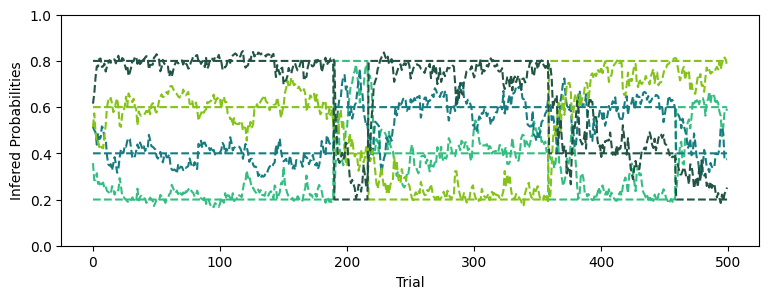

In [ ]:
soothing_greens = [
    "#34BE82",  # original
    "#167C80",  # much deeper teal/green (distinct from previous blue-green)
    "#84C318",  # lime green, more yellowish-green for difference
    "#235345"   # dark green, more greenish (was #213E3B)
]
plt.figure(figsize=(9, 3))
for i in range(4):
    plt.plot(result['true_association_probas'][0, :, i], color=soothing_greens[i], linestyle='--')
    plt.plot(result['probas_association'][0, :, i], linestyle='--', color=soothing_greens[i])
plt.ylabel('Infered Probabilities')
plt.xlabel('Trial')
plt.gca().set_ylim(0, 1)
#plt.savefig('figures/WP_trials_example_new_dec2025.pdf')
plt.gca().set_ylim(0, 1)

### With reversals and subjective

In [ ]:
# performances as a function of the sequence length
nb_agents = 30
nb_simuls = 100
association_probs = np.zeros((nb_agents, nb_simuls, 500, 4))
chosen_correct = np.zeros((nb_agents, nb_simuls, 500))
association_probs_reversals = np.zeros((nb_agents, nb_simuls, 500, 4))
ground_truth_probas_reversals = np.zeros((nb_agents, nb_simuls, 500, 4))
chosen_correct_reversals = np.zeros((nb_agents, nb_simuls, 500))
itrial = 300

for idx_agent in range(nb_agents):
    self = Worker(
        probabilistic_task(),
        "results/source/saved_models_5cues",
        "WP_GRU_agent{0}".format(idx_agent),
        w_emission=False,
        train_w_emission=False,
        train_in_cat_task_from_scratch=False,
        entropy_reg=None   
    )

    self.load_model()

    # generate data
    np.random.seed(idx_agent)
    self.env.generate_test_task(num_tasks=nb_simuls, num_trials=500, num_steps=5, probas=None, variable_length=False, tau=0.0)
    initial_probas = self.env.probas.copy()
    env_probas = np.zeros([nb_simuls, 500, 4])
    for i in range(nb_simuls):
        np.random.seed(i)
        env_probas[i] = self.env.probas[i, 0]
        while True:
            if (env_probas[i, 0] != env_probas[i, -1]).any():
                break
            env_probas[i, itrial:] = env_probas[i, 0][np.random.choice(np.arange(4), replace=False, size=4)]

    np.random.seed(idx_agent)
    self.env.generate_test_task(num_tasks=nb_simuls, num_trials=500, num_steps=5, probas=env_probas, variable_length=False)
    result1 = self.evaluate()
    chosen_correct_reversals[idx_agent] = (result1['logpredicts'].argmax(-1) == self.env.correct_weather).float().numpy()

    # psychometric curve
    np.random.seed(idx_agent)
    self.env.generate_test_task(num_tasks=nb_simuls, num_trials=500, num_steps=5, probas=initial_probas, variable_length=False, tau=0.0)
    result2 = self.evaluate()
    index_sorted = np.argsort(np.unique(self.env.probas, axis=1).squeeze(), axis=1)
    association_probs[idx_agent] = np.swapaxes(result2['probas_association'][np.arange(nb_simuls)[:, None],: , index_sorted].detach().numpy(), 1, 2)
    chosen_correct[idx_agent] = (result2['logpredicts'].argmax(-1) == self.env.correct_weather).float().numpy()

    # example of a reversal
    env_probas = np.zeros([nb_simuls, 500, 4])
    indexes_sorted = np.zeros([nb_simuls, 4], dtype=int)
    for i in range(nb_simuls):
        np.random.seed(i)
        probas_0 = np.round(self.env.probas[:, 0][i], 1)
        env_probas[i, :itrial] = probas_0
        probas_0_after_reversal = probas_0.copy()
        probas_0_after_reversal[probas_0 == 0.4] = 0.6
        probas_0_after_reversal[probas_0 == 0.6] = 0.8
        probas_0_after_reversal[probas_0 == 0.8] = 0.4
        env_probas[i, itrial:] = probas_0_after_reversal
        indexes_sorted[i] = index_sorted[i]

    self.env.probas = env_probas
    np.random.seed(idx_agent)
    self.env.generate_test_task(num_tasks=nb_simuls, num_trials=500, num_steps=5, probas=self.env.probas, variable_length=False)

    result1 = self.evaluate()
    association_probs_reversals[idx_agent] = np.swapaxes(result1['probas_association'][np.arange(nb_simuls)[:, None], :, indexes_sorted].detach().numpy(), 1, 2)
    ground_truth_probas_reversals[idx_agent] = np.swapaxes(result1['true_association_probas'][np.arange(nb_simuls)[:, None], :, indexes_sorted], 1, 2)

association_probs_reversals = np.mean(association_probs_reversals, axis=1)
ground_truth_probas_reversals = np.mean(ground_truth_probas_reversals, axis=1)
chosen_correct_reversals = np.mean(chosen_correct_reversals, axis=1)

association_probs = np.mean(association_probs, axis=1)
chosen_correct = np.mean(chosen_correct, axis=1)

loading model results/source/saved_models_5cues/WP_GRU_agent0_init_xavier_optim_Adam_episodeNbMax_50000_numUnits_32_trainWithEmission_False_trainInCatTaskFromScratch_False/model-50000.pth
loaded W_output_association
loaded gru_association.weight_ih_l0
loaded gru_association.weight_hh_l0
loaded gru_association.bias_ih_l0
loaded gru_association.bias_hh_l0
loading model results/source/saved_models_5cues/WP_GRU_agent1_init_xavier_optim_Adam_episodeNbMax_50000_numUnits_32_trainWithEmission_False_trainInCatTaskFromScratch_False/model-50000.pth
loaded W_output_association
loaded gru_association.weight_ih_l0
loaded gru_association.weight_hh_l0
loaded gru_association.bias_ih_l0
loaded gru_association.bias_hh_l0
loading model results/source/saved_models_5cues/WP_GRU_agent2_init_xavier_optim_Adam_episodeNbMax_50000_numUnits_32_trainWithEmission_False_trainInCatTaskFromScratch_False/model-50000.pth
loaded W_output_association
loaded gru_association.weight_ih_l0
loaded gru_association.weight_hh_l0


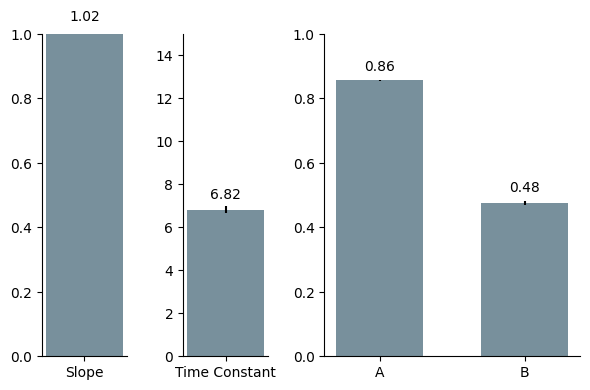

In [ ]:
from scipy.optimize import curve_fit
import numpy as np
import matplotlib.pyplot as plt

# Define the exponential recovery function
def exp_func(t, A, B, tau):
    return A + (B - A) * np.exp(-t / tau)

# Fit reversal parameters (A, B, tau) for each agent
reversal_params = np.zeros((len(chosen_correct_reversals), 3))
reversal_predictions = np.zeros((len(chosen_correct_reversals), 199))
for i, chosen_ in enumerate(chosen_correct_reversals):
    y = chosen_[301:]    
    t = np.arange(y.size)
    popt, pcov = curve_fit(exp_func, t, y, p0=[y[-1], y[0], 20])
    reversal_params[i] = popt  # [A, B, tau]
    reversal_predictions[i] = exp_func(t, *popt)
# Fit a slope for the psychometric curve for each agent
from sklearn.linear_model import LinearRegression
slopes = np.zeros(len(association_probs[:, -1]))
intercepts = np.zeros(len(association_probs[:, -1]))
for i, asso in enumerate(association_probs[:, -1]):
    lr = LinearRegression()
    X = np.array([0.2, 0.4, 0.6, 0.8]).reshape(-1, 1)
    y = asso
    lr.fit(X, y)
    slopes[i] = lr.coef_[0]
    intercepts[i] = lr.intercept_

n_agents = len(slopes)

color_all = "#607D8B"
color_A = "#607D8B"
color_B = "#A6A6A6"

# Create a gridspec so that the last subplot is twice as big as the first two
from matplotlib import gridspec
fig = plt.figure(figsize=(6, 4))
gs = gridspec.GridSpec(1, 3, width_ratios=[1, 1, 3])
axs = [fig.add_subplot(gs[0, i]) for i in range(3)]

# Plot 1: Slope Bar Plot
ax1 = axs[0]
mean_slope = np.mean(slopes)
sem_slope = np.std(slopes, ddof=1) / np.sqrt(n_agents)
bar1 = ax1.bar([0], [mean_slope], yerr=[sem_slope], color=color_all, capsize=0, alpha=0.85, width=0.7)
ax1.text(0, mean_slope + sem_slope + 0.01, f"{mean_slope:.2f}", ha='center', va='bottom', fontsize=10)
ax1.set_xticks([0])
ax1.set_xticklabels(["Slope"])
ax1.set_ylim([0, 1])
ax1.spines['right'].set_visible(False)
ax1.spines['top'].set_visible(False)

# Plot 2: Tau Bar Plot
ax2 = axs[1]
tau_vals = reversal_params[:,2]
mean_tau = np.mean(tau_vals)
sem_tau = np.std(tau_vals, ddof=1) / np.sqrt(n_agents)
bar2 = ax2.bar([0], [mean_tau], yerr=[sem_tau], color=color_all, capsize=0, alpha=0.85, width=0.7)
ax2.text(0, mean_tau + sem_tau + 0.2, f"{mean_tau:.2f}", ha='center', va='bottom', fontsize=10)
ax2.set_xticks([0])
ax2.set_xticklabels(["Time Constant"])
ax2.set_ylim([0, 15])
ax2.spines['right'].set_visible(False)
ax2.spines['top'].set_visible(False)

# Plot 3: Asymptote (A) and Initial (B) on the same plot
ax3 = axs[2]
A_vals = reversal_params[:,0]
B_vals = reversal_params[:,1]
mean_A = np.mean(A_vals)
sem_A = np.std(A_vals, ddof=1) / np.sqrt(n_agents)
mean_B = np.mean(B_vals)
sem_B = np.std(B_vals, ddof=1) / np.sqrt(n_agents)
width = 0.6

ax3.bar([0], [mean_A], yerr=[sem_A], color=color_A, capsize=0, alpha=0.85, width=width, label="Asymptote (A)")
ax3.bar([1], [mean_B], yerr=[sem_B], color=color_A, capsize=0, alpha=0.85, width=width, label="Initial (B)")
ax3.text(0, mean_A + sem_A + 0.02, f"{mean_A:.2f}", ha='center', va='bottom', fontsize=10)
ax3.text(1, mean_B + sem_B + 0.02, f"{mean_B:.2f}", ha='center', va='bottom', fontsize=10)
ax3.set_xticks([0, 1])
ax3.set_xticklabels(["A", "B"])
ax3.set_ylim(0, 1)
ax3.spines['right'].set_visible(False)
ax3.spines['top'].set_visible(False)

plt.tight_layout()
plt.savefig('figures/WP_reversal_binary_april2026_params.pdf')
plt.show()


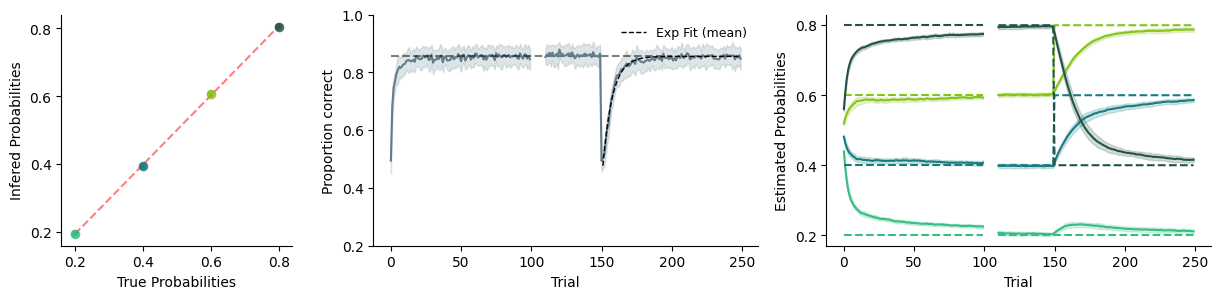

In [ ]:
soothing_greens =  ["#34BE82", "#167C80", "#84C318", "#235345"]

fig, axs = plt.subplots(1, 3, figsize=(15, 3), gridspec_kw={'width_ratios': [2, 3, 3]})
pmeans = association_probs[:, -1].mean(axis=0)
pstds = association_probs[:, -1].std(axis=0)
axs[0].scatter(np.array([0.2, 0.4, 0.6, 0.8]), pmeans, alpha=0.7, color=soothing_greens, s=20)
for i, color in enumerate(soothing_greens):
    axs[0].errorbar(np.array([0.2, 0.4, 0.6, 0.8])[i], pmeans[i], yerr=pstds[i], alpha=0.7, color=color, fmt='o')
axs[0].plot([0.2, 0.4, 0.6, 0.8], slopes.mean() * np.array([0.2, 0.4, 0.6, 0.8]) + intercepts.mean(), 'r--', alpha=0.5)
axs[0].set_ylabel('Infered Probabilities')
axs[0].set_xlabel('True Probabilities')
axs[0].set_xlim(0.16, 0.84)
axs[0].set_xticks([0.2, 0.4, 0.6, 0.8])
axs[0].set_ylim(0.16, 0.84)
axs[0].set_yticks([0.2, 0.4, 0.6, 0.8])
axs[0].set_aspect('equal', adjustable='box')
axs[0].spines['right'].set_visible(False)
axs[0].spines['top'].set_visible(False)

# reversal plots of beliefs
mean_correct = chosen_correct.mean(axis=0)
std_correct = chosen_correct.std(axis=0)
mean_correct_reversals = chosen_correct_reversals.mean(axis=0)
std_correct_reversals = chosen_correct_reversals.std(axis=0)
xx = np.arange(110, 250)
pmean_correct = mean_correct[:100]
pstd = std_correct[:100]
light_grey = "#607D8B"
axs[1].plot(pmean_correct, color=light_grey)
axs[1].plot( [0, 200], [mean_A, mean_A], 'k--', alpha=0.5)
axs[1].fill_between(np.arange(100), pmean_correct - pstd, pmean_correct + pstd, alpha=0.2, color=light_grey)
axs[1].set_ylabel('Proportion correct')
axs[1].set_xlabel('Trial')

axs[1].plot(xx, mean_correct_reversals[260:400], color=light_grey)
axs[1].fill_between(xx, mean_correct_reversals[260:400] - std_correct_reversals[260:400], mean_correct_reversals[260:400] + std_correct_reversals[260:400], alpha=0.2, color=light_grey)
axs[1].set_xticks([0, 50, 100, 150, 200, 250])
axs[1].set_ylim(0.2, 1.)
axs[1].set_yticks([0.2, 0.4, 0.6, 0.8, 1.0])
axs[1].spines['right'].set_visible(False)
axs[1].spines['top'].set_visible(False)

# Plot mean fitted exponential after reversal for the black mean
# Use exp_func(t, A, B, tau) and mean_B, mean_A, mean_tau from previous fit

t_fit = np.arange(151, 250)
exp_curve = exp_func(t_fit - 151, mean_A, mean_B, mean_tau)
axs[1].plot(t_fit, exp_curve[:len(t_fit)], "--", color='black', linewidth=1, label='Exp Fit (mean)')
axs[1].legend(frameon=False, fontsize=9, loc='upper right')

# reversal plots of beliefs
mean_association_probs_reversals = association_probs_reversals.mean(axis=0)
std_association_probs_reversals = association_probs_reversals.std(axis=0)
mean_ground_truth_probas_reversals = ground_truth_probas_reversals.mean(axis=0)
xx = np.arange(110, 250)
for i in range(4):
    pmean = association_probs.mean(axis=0)[:100, i]
    pstd = association_probs.std(axis=0)[:100, i]
    axs[2].plot(pmean, color=soothing_greens[i])
    axs[2].fill_between(np.arange(100), pmean - pstd, pmean + pstd, alpha=0.2, color=soothing_greens[i])
    p = np.array([0.2, 0.4, 0.6, 0.8])[i]
    axs[2].plot(p * np.ones(100), linestyle='--', color=soothing_greens[i])

axs[2].set_ylabel('Estimated Probabilities')
axs[2].set_xlabel('Trial')
for i in range(4):
    axs[2].plot(xx, mean_association_probs_reversals[260:400, i], color=soothing_greens[i])
    axs[2].plot(xx, mean_ground_truth_probas_reversals[260:400, i], linestyle='--', color=soothing_greens[i])
    axs[2].fill_between(xx, 
                        mean_association_probs_reversals[260:400, i] - std_association_probs_reversals[260:400, i], 
                        mean_association_probs_reversals[260:400, i] + std_association_probs_reversals[260:400, i], 
                        alpha=0.2, color=soothing_greens[i])
    axs[2].set_xticks([0, 50, 100, 150, 200, 250])
axs[2].set_ylim(0.17, 0.83)
axs[2].set_yticks([0.2, 0.4, 0.6, 0.8])
axs[2].spines['right'].set_visible(False)
axs[2].spines['top'].set_visible(False)
plt.savefig('figures/WP_reversal_binary_apr2026.pdf')

plt.show()

# With probabilistic feedbacks and giving the continuous reward

In [ ]:
from learn_to_infer import Worker
from task import probabilistic_task
import pandas as pd
import torch
import numpy as np
from matplotlib import pyplot as plt

import matplotlib as mpl
mpl.rcParams['pdf.fonttype'] = 42
mpl.rcParams['ps.fonttype'] = 42


In [ ]:
# performances as a function of the sequence length
nb_agents = 30
nb_simuls = 100
association_probs = np.zeros((nb_agents, nb_simuls, 500, 4))
chosen_correct = np.zeros((nb_agents, nb_simuls, 500))
association_probs_reversals = np.zeros((nb_agents, nb_simuls, 500, 4))
ground_truth_probas_reversals = np.zeros((nb_agents, nb_simuls, 500, 4))
chosen_correct_reversals = np.zeros((nb_agents, nb_simuls, 500))

for idx_agent in range(nb_agents):
    self = Worker(
        probabilistic_task(),
        "results/source/saved_models",
        "WP_GRU_agent{0}".format(idx_agent),
        w_emission=True,
        train_w_emission=False,
        train_in_cat_task_from_scratch=False,
        entropy_reg=None
    )

    self.load_model()

    # generate data
    np.random.seed(idx_agent)
    self.env.generate_test_task(num_tasks=nb_simuls, num_trials=500, num_steps=5, probas=None, variable_length=False, tau=0.0)
    initial_probas = self.env.probas.copy()
    env_probas = np.zeros([nb_simuls, 500, 4])
    for i in range(nb_simuls):
        np.random.seed(i)
        env_probas[i] = self.env.probas[i, 0]
        while True:
            if (env_probas[i, 0] != env_probas[i, -1]).any():
                break
            env_probas[i, itrial:] = env_probas[i, 0][np.random.choice(np.arange(4), replace=False, size=4)]

    np.random.seed(idx_agent)
    self.env.generate_test_task(num_tasks=nb_simuls, num_trials=500, num_steps=5, probas=env_probas, variable_length=False)
    result1 = self.evaluate(use_probabilitistic_reward=True)
    chosen_correct_reversals[idx_agent] = (result1['logpredicts'].argmax(-1) == self.env.correct_weather).float().numpy()

    # psychometric curve
    np.random.seed(idx_agent)
    self.env.generate_test_task(num_tasks=nb_simuls, num_trials=500, num_steps=5, probas=initial_probas, variable_length=False, tau=0.0)
    result2 = self.evaluate(use_probabilitistic_reward=True)
    index_sorted = np.argsort(np.unique(self.env.probas, axis=1).squeeze(), axis=1)
    association_probs[idx_agent] = np.swapaxes(result2['probas_association'][np.arange(nb_simuls)[:, None],: , index_sorted].detach().numpy(), 1, 2)
    chosen_correct[idx_agent] = (result2['logpredicts'].argmax(-1) == self.env.correct_weather).float().numpy()

    # example of a reversal
    env_probas = np.zeros([nb_simuls, 500, 4])
    indexes_sorted = np.zeros([nb_simuls, 4], dtype=int)
    for i in range(nb_simuls):
        np.random.seed(i)
        probas_0 = np.round(self.env.probas[:, 0][i], 1)
        env_probas[i, :itrial] = probas_0
        probas_0_after_reversal = probas_0.copy()
        probas_0_after_reversal[probas_0 == 0.4] = 0.6
        probas_0_after_reversal[probas_0 == 0.6] = 0.8
        probas_0_after_reversal[probas_0 == 0.8] = 0.4
        env_probas[i, itrial:] = probas_0_after_reversal
        indexes_sorted[i] = index_sorted[i]

    self.env.probas = env_probas
    np.random.seed(idx_agent)
    self.env.generate_test_task(num_tasks=nb_simuls, num_trials=500, num_steps=5, probas=self.env.probas, variable_length=False)

    result1 = self.evaluate(use_probabilitistic_reward=True)
    association_probs_reversals[idx_agent] = np.swapaxes(result1['probas_association'][np.arange(nb_simuls)[:, None], :, indexes_sorted].detach().numpy(), 1, 2)
    ground_truth_probas_reversals[idx_agent] = np.swapaxes(result1['true_association_probas'][np.arange(nb_simuls)[:, None], :, indexes_sorted], 1, 2)

association_probs_reversals = np.mean(association_probs_reversals, axis=1)
ground_truth_probas_reversals = np.mean(ground_truth_probas_reversals, axis=1)
chosen_correct_reversals = np.mean(chosen_correct_reversals, axis=1)

association_probs = np.mean(association_probs, axis=1)
chosen_correct = np.mean(chosen_correct, axis=1)

loaded the emission model with 50000 iterations
loading model results/source/saved_models/WP_GRU_agent0_init_xavier_optim_Adam_episodeNbMax_50000_numUnits_32_trainWithEmission_False_trainInCatTaskFromScratch_False/model-50000.pth
loaded W_output_association
key W_output_emission not found in state_dict
loaded gru_association.weight_ih_l0
loaded gru_association.weight_hh_l0
loaded gru_association.bias_ih_l0
loaded gru_association.bias_hh_l0
key gru_emission.weight_ih_l0 not found in state_dict
key gru_emission.weight_hh_l0 not found in state_dict
key gru_emission.bias_ih_l0 not found in state_dict
key gru_emission.bias_hh_l0 not found in state_dict
loaded the association model
loading model results/source/saved_models/WP_GRU_agent0_init_xavier_optim_Adam_episodeNbMax_50000_numUnits_32_trainWithEmission_False_trainInCatTaskFromScratch_False/model-50000.pth
loaded W_output_association
key W_output_emission not found in state_dict
loaded gru_association.weight_ih_l0
loaded gru_association.

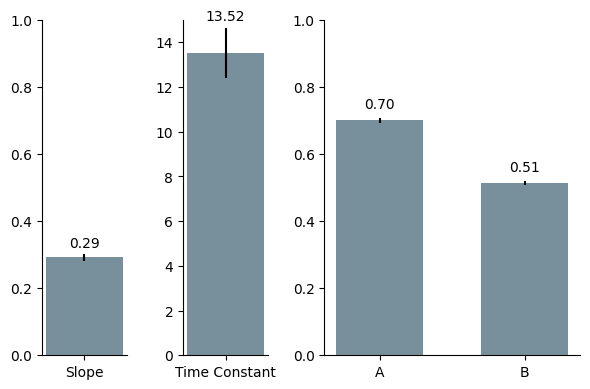

In [ ]:
from scipy.optimize import curve_fit
import numpy as np
import matplotlib.pyplot as plt

# Define the exponential recovery function
def exp_func(t, A, B, tau):
    return A + (B - A) * np.exp(-t / tau)

# Fit reversal parameters (A, B, tau) for each agent
reversal_params = np.zeros((len(chosen_correct_reversals), 3))
reversal_predictions = np.zeros((len(chosen_correct_reversals), 199))
for i, chosen_ in enumerate(chosen_correct_reversals):
    y = chosen_[301:]
    t = np.arange(y.size)
    popt, pcov = curve_fit(exp_func, t, y, p0=[y[-1], y[0], 20])
    reversal_params[i] = popt  # [A, B, tau]
    reversal_predictions[i] = exp_func(t, *popt)
# Fit a slope for the psychometric curve for each agent
from sklearn.linear_model import LinearRegression
slopes = np.zeros(len(association_probs[:, -1]))
intercepts = np.zeros(len(association_probs[:, -1]))
for i, asso in enumerate(association_probs[:, -1]):
    lr = LinearRegression()
    X = np.array([0.2, 0.4, 0.6, 0.8]).reshape(-1, 1)
    y = asso
    lr.fit(X, y)
    slopes[i] = lr.coef_[0]
    intercepts[i] = lr.intercept_

n_agents = len(slopes)

color_all = "#607D8B"
color_A = "#607D8B"
color_B = "#A6A6A6"

# Create a gridspec so that the last subplot is twice as big as the first two
from matplotlib import gridspec
fig = plt.figure(figsize=(6, 4))
gs = gridspec.GridSpec(1, 3, width_ratios=[1, 1, 3])
axs = [fig.add_subplot(gs[0, i]) for i in range(3)]

# Plot 1: Slope Bar Plot
ax1 = axs[0]
mean_slope = np.mean(slopes)
sem_slope = np.std(slopes, ddof=1) / np.sqrt(n_agents)
mean_intercept = np.mean(intercepts)
bar1 = ax1.bar([0], [mean_slope], yerr=[sem_slope], color=color_all, capsize=0, alpha=0.85, width=0.7)
ax1.text(0, mean_slope + sem_slope + 0.01, f"{mean_slope:.2f}", ha='center', va='bottom', fontsize=10)
ax1.set_xticks([0])
ax1.set_xticklabels(["Slope"])
ax1.set_ylim([0, 1])
ax1.spines['right'].set_visible(False)
ax1.spines['top'].set_visible(False)

# Plot 2: Tau Bar Plot
ax2 = axs[1]
tau_vals = reversal_params[:,2]
mean_tau = np.mean(tau_vals)
sem_tau = np.std(tau_vals, ddof=1) / np.sqrt(n_agents)
bar2 = ax2.bar([0], [mean_tau], yerr=[sem_tau], color=color_all, capsize=0, alpha=0.85, width=0.7)
ax2.text(0, mean_tau + sem_tau + 0.2, f"{mean_tau:.2f}", ha='center', va='bottom', fontsize=10)
ax2.set_xticks([0])
ax2.set_xticklabels(["Time Constant"])
ax2.set_ylim([0, 15])
ax2.spines['right'].set_visible(False)
ax2.spines['top'].set_visible(False)

# Plot 3: Asymptote (A) and Initial (B) on the same plot
ax3 = axs[2]
A_vals = reversal_params[:,0]
B_vals = reversal_params[:,1]
mean_A = np.mean(A_vals)
sem_A = np.std(A_vals, ddof=1) / np.sqrt(n_agents)
mean_B = np.mean(B_vals)
sem_B = np.std(B_vals, ddof=1) / np.sqrt(n_agents)
width = 0.6

ax3.bar([0], [mean_A], yerr=[sem_A], color=color_A, capsize=0, alpha=0.85, width=width, label="Asymptote (A)")
ax3.bar([1], [mean_B], yerr=[sem_B], color=color_A, capsize=0, alpha=0.85, width=width, label="Initial (B)")
ax3.text(0, mean_A + sem_A + 0.02, f"{mean_A:.2f}", ha='center', va='bottom', fontsize=10)
ax3.text(1, mean_B + sem_B + 0.02, f"{mean_B:.2f}", ha='center', va='bottom', fontsize=10)
ax3.set_xticks([0, 1])
ax3.set_xticklabels(["A", "B"])
ax3.set_ylim(0, 1)
ax3.spines['right'].set_visible(False)
ax3.spines['top'].set_visible(False)

plt.tight_layout()
plt.savefig('figures/WP_reversal_w_probabilistic_feedback_april2026_params.pdf')
plt.show()


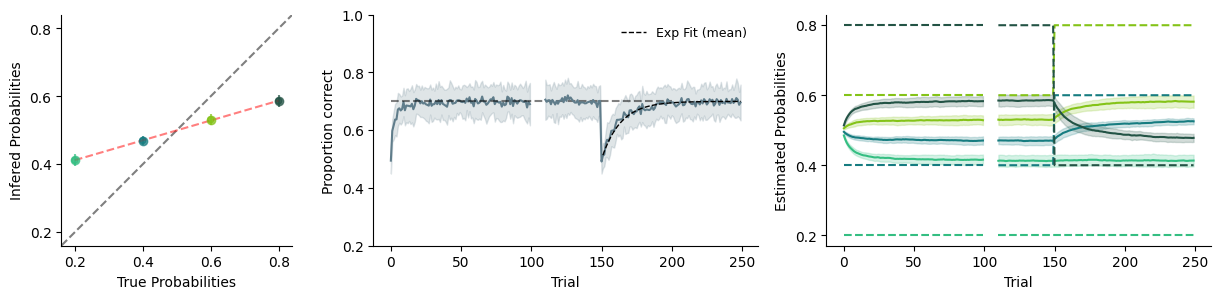

In [ ]:
soothing_greens =  ["#34BE82", "#167C80", "#84C318", "#235345"]

fig, axs = plt.subplots(1, 3, figsize=(15, 3), gridspec_kw={'width_ratios': [2, 3, 3]})
pmeans = association_probs[:, -1].mean(axis=0)
pstds = association_probs[:, -1].std(axis=0)
axs[0].scatter(np.array([0.2, 0.4, 0.6, 0.8]), pmeans, alpha=0.7, color=soothing_greens, s=20)
for i, color in enumerate(soothing_greens):
    axs[0].errorbar(np.array([0.2, 0.4, 0.6, 0.8])[i], pmeans[i], yerr=pstds[i], alpha=0.7, color=color, fmt='o')
axs[0].plot([0, 1], [0, 1], 'k--', alpha=0.5, label='x=y')
axs[0].set_ylabel('Infered Probabilities')
axs[0].set_xlabel('True Probabilities')
axs[0].set_xlim(0.16, 0.84)
axs[0].set_xticks([0.2, 0.4, 0.6, 0.8])
axs[0].set_ylim(0.16, 0.84)
axs[0].set_yticks([0.2, 0.4, 0.6, 0.8])
axs[0].set_aspect('equal', adjustable='box')
axs[0].spines['right'].set_visible(False)
axs[0].spines['top'].set_visible(False)
axs[0].plot([0.2, 0.4, 0.6, 0.8], slopes.mean() * np.array([0.2, 0.4, 0.6, 0.8]) + intercepts.mean(), 'r--', alpha=0.5)

# reversal plots of beliefs
mean_correct = chosen_correct.mean(axis=0)
std_correct = chosen_correct.std(axis=0)
mean_correct_reversals = chosen_correct_reversals.mean(axis=0)
std_correct_reversals = chosen_correct_reversals.std(axis=0)
xx = np.arange(110, 250)
pmean_correct = mean_correct[:100]
pstd = std_correct[:100]
light_grey = "#607D8B"
axs[1].plot(pmean_correct, color=light_grey)
axs[1].plot( [0, 200], [mean_A, mean_A], 'k--', alpha=0.5)
axs[1].fill_between(np.arange(100), pmean_correct - pstd, pmean_correct + pstd, alpha=0.2, color=light_grey)
axs[1].set_ylabel('Proportion correct')
axs[1].set_xlabel('Trial')
axs[1].plot(xx, mean_correct_reversals[260:400], color=light_grey)
axs[1].fill_between(xx, mean_correct_reversals[260:400] - std_correct_reversals[260:400], mean_correct_reversals[260:400] + std_correct_reversals[260:400], alpha=0.2, color=light_grey)
axs[1].set_xticks([0, 50, 100, 150, 200, 250])
axs[1].set_ylim(0.2, 1.)
axs[1].set_yticks([0.2, 0.4, 0.6, 0.8, 1.0])
axs[1].spines['right'].set_visible(False)
axs[1].spines['top'].set_visible(False)


# Plot mean fitted exponential after reversal for the black mean
# Use exp_func(t, A, B, tau) and mean_B, mean_A, mean_tau from previous fit
if 'mean_A' in locals() and 'mean_B' in locals() and 'mean_tau' in locals():
    t_fit = np.arange(151, 250)
    exp_curve = exp_func(t_fit - 151, mean_A, mean_B, mean_tau)
    axs[1].plot(t_fit, exp_curve[:len(t_fit)], "--", color='black', linewidth=1, label='Exp Fit (mean)')
    axs[1].legend(frameon=False, fontsize=9, loc='upper right')
    
# reversal plots of beliefs
mean_association_probs_reversals = association_probs_reversals.mean(axis=0)
std_association_probs_reversals = association_probs_reversals.std(axis=0)
mean_ground_truth_probas_reversals = ground_truth_probas_reversals.mean(axis=0)
xx = np.arange(110, 250)
for i in range(4):
    pmean = association_probs.mean(axis=0)[:100, i]
    pstd = association_probs.std(axis=0)[:100, i]
    axs[2].plot(pmean, color=soothing_greens[i])
    axs[2].fill_between(np.arange(100), pmean - pstd, pmean + pstd, alpha=0.2, color=soothing_greens[i])
    p = np.array([0.2, 0.4, 0.6, 0.8])[i]
    axs[2].plot(p * np.ones(100), linestyle='--', color=soothing_greens[i])
axs[2].set_ylabel('Estimated Probabilities')
axs[2].set_xlabel('Trial')
for i in range(4):
    axs[2].plot(xx, mean_association_probs_reversals[260:400, i], color=soothing_greens[i])
    axs[2].plot(xx, mean_ground_truth_probas_reversals[260:400, i], linestyle='--', color=soothing_greens[i])
    axs[2].fill_between(xx, 
                        mean_association_probs_reversals[260:400, i] - std_association_probs_reversals[260:400, i], 
                        mean_association_probs_reversals[260:400, i] + std_association_probs_reversals[260:400, i], 
                        alpha=0.2, color=soothing_greens[i])
    axs[2].set_xticks([0, 50, 100, 150, 200, 250])
axs[2].set_ylim(0.17, 0.83)
axs[2].set_yticks([0.2, 0.4, 0.6, 0.8])
axs[2].spines['right'].set_visible(False)
axs[2].spines['top'].set_visible(False)
plt.savefig('figures/WP_reversal_w_prob_feedback_april2026.pdf')

plt.show()

# With probabilistic feedbacks and using the previously learned emission

In [ ]:
# performances as a function of the sequence length
itrial = 300
nb_agents = 30
nb_simuls = 100
association_probs = np.zeros((nb_agents, nb_simuls, 500, 4))
chosen_correct = np.zeros((nb_agents, nb_simuls, 500))
association_probs_reversals = np.zeros((nb_agents, nb_simuls, 500, 4))
ground_truth_probas_reversals = np.zeros((nb_agents, nb_simuls, 500, 4))
chosen_correct_reversals = np.zeros((nb_agents, nb_simuls, 500))

for idx_agent in range(nb_agents):
    self = Worker(
        probabilistic_task(),
        "results/source/saved_models",
        "WP_GRU_agent{0}".format(idx_agent),
        w_emission=True,
        train_w_emission=False,
        train_in_cat_task_from_scratch=False,
        entropy_reg=None
    )

    self.load_model()

    # generate data
    np.random.seed(idx_agent)
    self.env.generate_test_task(num_tasks=nb_simuls, num_trials=500, num_steps=5, probas=None, variable_length=False, tau=0.0)
    initial_probas = self.env.probas.copy()
    env_probas = np.zeros([nb_simuls, 500, 4])
    for i in range(nb_simuls):
        np.random.seed(i)
        env_probas[i] = self.env.probas[i, 0]
        while True:
            if (env_probas[i, 0] != env_probas[i, -1]).any():
                break
            env_probas[i, itrial:] = env_probas[i, 0][np.random.choice(np.arange(4), replace=False, size=4)]

    np.random.seed(idx_agent)
    self.env.generate_test_task(num_tasks=nb_simuls, num_trials=500, num_steps=5, probas=env_probas, variable_length=False)
    result1 = self.evaluate()
    chosen_correct_reversals[idx_agent] = (result1['logpredicts'].argmax(-1) == self.env.correct_weather).float().numpy()

    # psychometric curve
    np.random.seed(idx_agent)
    self.env.generate_test_task(num_tasks=nb_simuls, num_trials=500, num_steps=5, probas=initial_probas, variable_length=False, tau=0.0)
    result2 = self.evaluate()
    index_sorted = np.argsort(np.unique(self.env.probas, axis=1).squeeze(), axis=1)
    association_probs[idx_agent] = np.swapaxes(result2['probas_association'][np.arange(nb_simuls)[:, None],: , index_sorted].detach().numpy(), 1, 2)
    chosen_correct[idx_agent] = (result2['logpredicts'].argmax(-1) == self.env.correct_weather).float().numpy()

    # example of a reversal
    env_probas = np.zeros([nb_simuls, 500, 4])
    indexes_sorted = np.zeros([nb_simuls, 4], dtype=int)
    for i in range(nb_simuls):
        np.random.seed(i)
        probas_0 = np.round(self.env.probas[:, 0][i], 1)
        env_probas[i, :itrial] = probas_0
        probas_0_after_reversal = probas_0.copy()
        probas_0_after_reversal[probas_0 == 0.4] = 0.6
        probas_0_after_reversal[probas_0 == 0.6] = 0.8
        probas_0_after_reversal[probas_0 == 0.8] = 0.4
        env_probas[i, itrial:] = probas_0_after_reversal
        indexes_sorted[i] = index_sorted[i]

    self.env.probas = env_probas
    np.random.seed(idx_agent)
    self.env.generate_test_task(num_tasks=nb_simuls, num_trials=500, num_steps=5, probas=self.env.probas, variable_length=False)

    result1 = self.evaluate()
    association_probs_reversals[idx_agent] = np.swapaxes(result1['probas_association'][np.arange(nb_simuls)[:, None], :, indexes_sorted].detach().numpy(), 1, 2)
    ground_truth_probas_reversals[idx_agent] = np.swapaxes(result1['true_association_probas'][np.arange(nb_simuls)[:, None], :, indexes_sorted], 1, 2)

association_probs_reversals = np.mean(association_probs_reversals, axis=1)
ground_truth_probas_reversals = np.mean(ground_truth_probas_reversals, axis=1)
chosen_correct_reversals = np.mean(chosen_correct_reversals, axis=1)

association_probs = np.mean(association_probs, axis=1)
chosen_correct = np.mean(chosen_correct, axis=1)

loaded the emission model with 50000 iterations
loading model results/source/saved_models/WP_GRU_agent0_init_xavier_optim_Adam_episodeNbMax_50000_numUnits_32_trainWithEmission_False_trainInCatTaskFromScratch_False/model-50000.pth
loaded W_output_association
key W_output_emission not found in state_dict
loaded gru_association.weight_ih_l0
loaded gru_association.weight_hh_l0
loaded gru_association.bias_ih_l0
loaded gru_association.bias_hh_l0
key gru_emission.weight_ih_l0 not found in state_dict
key gru_emission.weight_hh_l0 not found in state_dict
key gru_emission.bias_ih_l0 not found in state_dict
key gru_emission.bias_hh_l0 not found in state_dict
loaded the association model
loading model results/source/saved_models/WP_GRU_agent0_init_xavier_optim_Adam_episodeNbMax_50000_numUnits_32_trainWithEmission_False_trainInCatTaskFromScratch_False/model-50000.pth
loaded W_output_association
key W_output_emission not found in state_dict
loaded gru_association.weight_ih_l0
loaded gru_association.

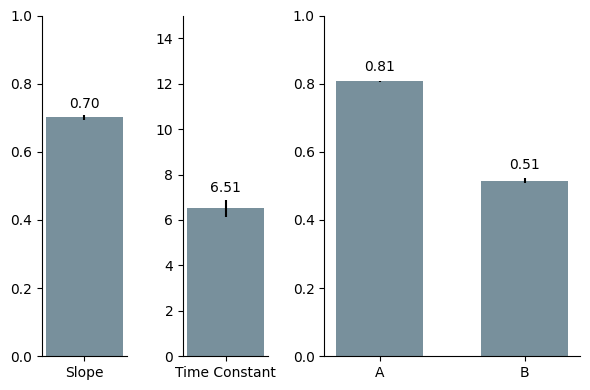

In [ ]:
from scipy.optimize import curve_fit
import numpy as np
import matplotlib.pyplot as plt

# Define the exponential recovery function
def exp_func(t, A, B, tau):
    return A + (B - A) * np.exp(-t / tau)

# Fit reversal parameters (A, B, tau) for each agent
reversal_params = np.zeros((len(chosen_correct_reversals), 3))
reversal_predictions = np.zeros((len(chosen_correct_reversals), 199))
for i, chosen_ in enumerate(chosen_correct_reversals):
    y = chosen_[301:]
    t = np.arange(y.size)
    popt, pcov = curve_fit(exp_func, t, y, p0=[y[-1], y[0], 20])
    reversal_params[i] = popt  # [A, B, tau]
    reversal_predictions[i] = exp_func(t, *popt)
# Fit a slope for the psychometric curve for each agent
from sklearn.linear_model import LinearRegression
slopes = np.zeros(len(association_probs[:, -1]))
intercepts = np.zeros(len(association_probs[:, -1]))
for i, asso in enumerate(association_probs[:, -1]):
    lr = LinearRegression()
    X = np.array([0.2, 0.4, 0.6, 0.8]).reshape(-1, 1)
    y = asso
    lr.fit(X, y)
    slopes[i] = lr.coef_[0]
    intercepts[i] = lr.intercept_

n_agents = len(slopes)

color_all = "#607D8B"
color_A = "#607D8B"
color_B = "#A6A6A6"

# Create a gridspec so that the last subplot is twice as big as the first two
from matplotlib import gridspec
fig = plt.figure(figsize=(6, 4))
gs = gridspec.GridSpec(1, 3, width_ratios=[1, 1, 3])
axs = [fig.add_subplot(gs[0, i]) for i in range(3)]

# Plot 1: Slope Bar Plot
ax1 = axs[0]
mean_slope = np.mean(slopes)
sem_slope = np.std(slopes, ddof=1) / np.sqrt(n_agents)
bar1 = ax1.bar([0], [mean_slope], yerr=[sem_slope], color=color_all, capsize=0, alpha=0.85, width=0.7)
ax1.text(0, mean_slope + sem_slope + 0.01, f"{mean_slope:.2f}", ha='center', va='bottom', fontsize=10)
ax1.set_xticks([0])
ax1.set_xticklabels(["Slope"])
ax1.set_ylim([0, 1])
ax1.spines['right'].set_visible(False)
ax1.spines['top'].set_visible(False)

# Plot 2: Tau Bar Plot
ax2 = axs[1]
tau_vals = reversal_params[:,2]
mean_tau = np.mean(tau_vals)
sem_tau = np.std(tau_vals, ddof=1) / np.sqrt(n_agents)
bar2 = ax2.bar([0], [mean_tau], yerr=[sem_tau], color=color_all, capsize=0, alpha=0.85, width=0.7)
ax2.text(0, mean_tau + sem_tau + 0.2, f"{mean_tau:.2f}", ha='center', va='bottom', fontsize=10)
ax2.set_xticks([0])
ax2.set_xticklabels(["Time Constant"])
ax2.set_ylim([0, 15])
ax2.spines['right'].set_visible(False)
ax2.spines['top'].set_visible(False)

# Plot 3: Asymptote (A) and Initial (B) on the same plot
ax3 = axs[2]
A_vals = reversal_params[:,0]
B_vals = reversal_params[:,1]
mean_A = np.mean(A_vals)
sem_A = np.std(A_vals, ddof=1) / np.sqrt(n_agents)
mean_B = np.mean(B_vals)
sem_B = np.std(B_vals, ddof=1) / np.sqrt(n_agents)
width = 0.6

ax3.bar([0], [mean_A], yerr=[sem_A], color=color_A, capsize=0, alpha=0.85, width=width, label="Asymptote (A)")
ax3.bar([1], [mean_B], yerr=[sem_B], color=color_A, capsize=0, alpha=0.85, width=width, label="Initial (B)")
ax3.text(0, mean_A + sem_A + 0.02, f"{mean_A:.2f}", ha='center', va='bottom', fontsize=10)
ax3.text(1, mean_B + sem_B + 0.02, f"{mean_B:.2f}", ha='center', va='bottom', fontsize=10)
ax3.set_xticks([0, 1])
ax3.set_xticklabels(["A", "B"])
ax3.set_ylim(0, 1)
ax3.spines['right'].set_visible(False)
ax3.spines['top'].set_visible(False)

plt.tight_layout()
plt.savefig('figures/WP_reversal_w_emission_april2026_params.pdf')
plt.show()


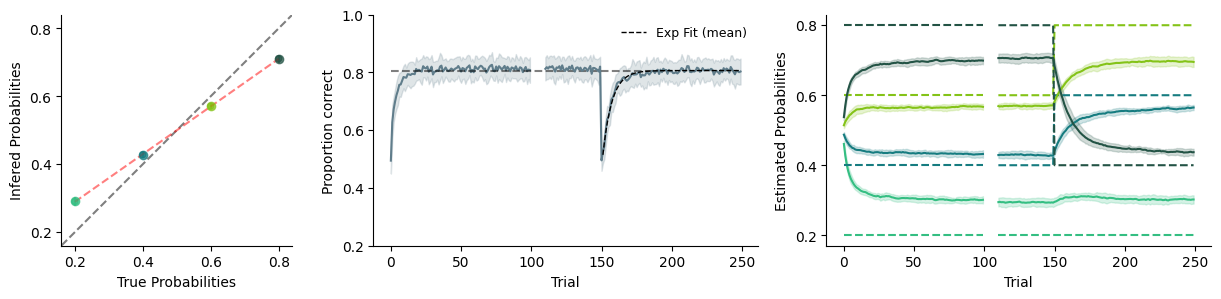

In [ ]:
soothing_greens =  ["#34BE82", "#167C80", "#84C318", "#235345"]

fig, axs = plt.subplots(1, 3, figsize=(15, 3), gridspec_kw={'width_ratios': [2, 3, 3]})
pmeans = association_probs[:, -1].mean(axis=0)
pstds = association_probs[:, -1].std(axis=0)
axs[0].scatter(np.array([0.2, 0.4, 0.6, 0.8]), pmeans, alpha=0.7, color=soothing_greens, s=20)
for i, color in enumerate(soothing_greens):
    axs[0].errorbar(np.array([0.2, 0.4, 0.6, 0.8])[i], pmeans[i], yerr=pstds[i], alpha=0.7, color=color, fmt='o')
axs[0].plot([0, 1], [0, 1], 'k--', alpha=0.5, label='x=y')
axs[0].set_ylabel('Infered Probabilities')
axs[0].set_xlabel('True Probabilities')
axs[0].set_xlim(0.16, 0.84)
axs[0].set_xticks([0.2, 0.4, 0.6, 0.8])
axs[0].set_ylim(0.16, 0.84)
axs[0].set_yticks([0.2, 0.4, 0.6, 0.8])
axs[0].set_aspect('equal', adjustable='box')
axs[0].spines['right'].set_visible(False)
axs[0].spines['top'].set_visible(False)
axs[0].plot([0.2, 0.4, 0.6, 0.8], slopes.mean() * np.array([0.2, 0.4, 0.6, 0.8]) + intercepts.mean(), 'r--', alpha=0.5)

# reversal plots of beliefs
mean_correct = chosen_correct.mean(axis=0)
std_correct = chosen_correct.std(axis=0)
mean_correct_reversals = chosen_correct_reversals.mean(axis=0)
std_correct_reversals = chosen_correct_reversals.std(axis=0)
xx = np.arange(110, 250)
pmean_correct = mean_correct[:100]
pstd = std_correct[:100]
light_grey = "#607D8B"
axs[1].plot(pmean_correct, color=light_grey)
axs[1].plot( [0, 200], [mean_A, mean_A], 'k--', alpha=0.5)
axs[1].fill_between(np.arange(100), pmean_correct - pstd, pmean_correct + pstd, alpha=0.2, color=light_grey)
axs[1].set_ylabel('Proportion correct')
axs[1].set_xlabel('Trial')
axs[1].plot(xx, mean_correct_reversals[260:400], color=light_grey)
axs[1].fill_between(xx, mean_correct_reversals[260:400] - std_correct_reversals[260:400], mean_correct_reversals[260:400] + std_correct_reversals[260:400], alpha=0.2, color=light_grey)
axs[1].set_xticks([0, 50, 100, 150, 200, 250])
axs[1].set_ylim(0.2, 1.)
axs[1].set_yticks([0.2, 0.4, 0.6, 0.8, 1.0])
axs[1].spines['right'].set_visible(False)
axs[1].spines['top'].set_visible(False)

# Plot mean fitted exponential after reversal for the black mean
# Use exp_func(t, A, B, tau) and mean_B, mean_A, mean_tau from previous fit
if 'mean_A' in locals() and 'mean_B' in locals() and 'mean_tau' in locals():
    t_fit = np.arange(151, 250)
    exp_curve = exp_func(t_fit - 151, mean_A, mean_B, mean_tau)
    axs[1].plot(t_fit, exp_curve[:len(t_fit)], "--", color='black', linewidth=1, label='Exp Fit (mean)')
    axs[1].legend(frameon=False, fontsize=9, loc='upper right')
    
# reversal plots of beliefs
mean_association_probs_reversals = association_probs_reversals.mean(axis=0)
std_association_probs_reversals = association_probs_reversals.std(axis=0)
mean_ground_truth_probas_reversals = ground_truth_probas_reversals.mean(axis=0)
xx = np.arange(110, 250)
for i in range(4):
    pmean = association_probs.mean(axis=0)[:100, i]
    pstd = association_probs.std(axis=0)[:100, i]
    axs[2].plot(pmean, color=soothing_greens[i])
    axs[2].fill_between(np.arange(100), pmean - pstd, pmean + pstd, alpha=0.2, color=soothing_greens[i])
    p = np.array([0.2, 0.4, 0.6, 0.8])[i]
    axs[2].plot(p * np.ones(100), linestyle='--', color=soothing_greens[i])
axs[2].set_ylabel('Estimated Probabilities')
axs[2].set_xlabel('Trial')
for i in range(4):
    axs[2].plot(xx, mean_association_probs_reversals[260:400, i], color=soothing_greens[i])
    axs[2].plot(xx, mean_ground_truth_probas_reversals[260:400, i], linestyle='--', color=soothing_greens[i])
    axs[2].fill_between(xx, 
                        mean_association_probs_reversals[260:400, i] - std_association_probs_reversals[260:400, i], 
                        mean_association_probs_reversals[260:400, i] + std_association_probs_reversals[260:400, i], 
                        alpha=0.2, color=soothing_greens[i])
    axs[2].set_xticks([0, 50, 100, 150, 200, 250])
axs[2].set_ylim(0.17, 0.83)
axs[2].set_yticks([0.2, 0.4, 0.6, 0.8])
axs[2].spines['right'].set_visible(False)
axs[2].spines['top'].set_visible(False)
plt.savefig('figures/WP_reversal_w_emission_april2026.pdf')

plt.show()

In [ ]:
from learn_to_infer import Worker
from task import probabilistic_task
import pandas as pd
import torch
import numpy as np
from matplotlib import pyplot as plt

import matplotlib as mpl
mpl.rcParams['pdf.fonttype'] = 42
mpl.rcParams['ps.fonttype'] = 42

import numpy as np

# Define the parameter ranges
range_of_ffs = [0.05, 0.1, 0.15, 0.2, 0.25, 0.3]
range_of_mus = [0.05, 0.1, 0.15, 0.20, 0.3, 0.45, 0.65]

nb_simuls = 1000
ffs_grid, mus_grid = np.meshgrid(range_of_ffs, range_of_mus, indexing='ij')
ffs, mus = ffs_grid.ravel(), mus_grid.ravel()

nb_repeats = int(nb_simuls / len(ffs)) + 1
ffs = np.tile(ffs, nb_repeats)[:nb_simuls]
mus = np.tile(mus, nb_repeats)[:nb_simuls]

nb_bins_falsefeedback = len(range_of_ffs)

# performances as a function of the sequence length
nb_agents = 30
false_positive_rate_function_of_trials = np.zeros((nb_agents, nb_simuls, 200))
emission_function_of_trials = np.zeros([nb_agents, nb_simuls, 10, 201])

for idx_agent in range(nb_agents):
    self = Worker(
        probabilistic_task(),
        "results/source/saved_models",
        "WP_GRU_agent{0}".format(idx_agent),
        w_emission=True,
        train_w_emission=False,
        train_in_cat_task_from_scratch=False,
        entropy_reg=None
    )

    self.load_model()

    np.random.seed(idx_agent)
    self.env.generate_test_task(num_tasks=nb_simuls, num_trials=200, num_steps=5, probas=None, variable_length=True, tau=0.0, ffs=ffs, mus=mus)
    result = self.evaluate()
    index_sorted = np.argsort(np.unique(self.env.probas, axis=1).squeeze(), axis=1)
    false_positive_rate_function_of_trials[idx_agent] = result['params_emission'][:, :, :100].sum(-1).detach().numpy()


loaded the emission model with 50000 iterations
loading model results/source/saved_models/WP_GRU_agent0_init_xavier_optim_Adam_episodeNbMax_50000_numUnits_32_trainWithEmission_False_trainInCatTaskFromScratch_False/model-50000.pth
loaded W_output_association
key W_output_emission not found in state_dict
loaded gru_association.weight_ih_l0
loaded gru_association.weight_hh_l0
loaded gru_association.bias_ih_l0
loaded gru_association.bias_hh_l0
key gru_emission.weight_ih_l0 not found in state_dict
key gru_emission.weight_hh_l0 not found in state_dict
key gru_emission.bias_ih_l0 not found in state_dict
key gru_emission.bias_hh_l0 not found in state_dict
loaded the association model
loading model results/source/saved_models/WP_GRU_agent0_init_xavier_optim_Adam_episodeNbMax_50000_numUnits_32_trainWithEmission_False_trainInCatTaskFromScratch_False/model-50000.pth
loaded W_output_association
key W_output_emission not found in state_dict
loaded gru_association.weight_ih_l0
loaded gru_association.

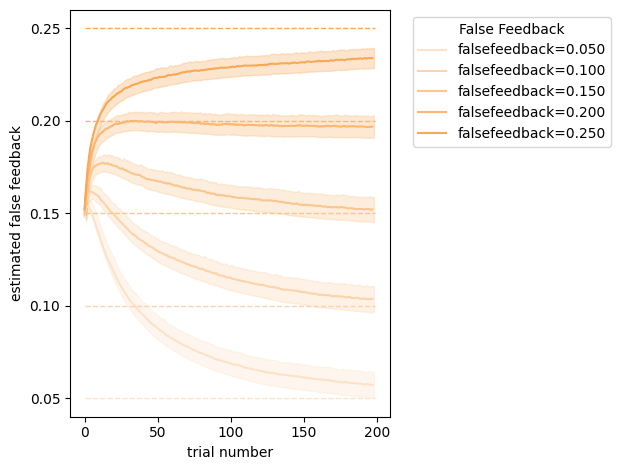

In [ ]:
unique_falsefeedback = np.unique(ffs)[:-1]
estimations_means = np.hstack([false_positive_rate_function_of_trials[:, (ffs==v)].mean(axis=1, keepdims=True) for v in unique_falsefeedback])

import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import numpy as np

import matplotlib as mpl
mpl.rcParams['pdf.fonttype'] = 42
mpl.rcParams['pdf.use14corefonts'] = True  # Ensures text remains text for post-processing (editable in Illustrator etc.)
mpl.rcParams['ps.fonttype'] = 42
mpl.rcParams['ps.useafm'] = True  # Use Type 1 fonts for editable output

# Create a colormap gradient of "#F8993A"
base_color = "#F8993A"
# We'll make a light-to-dark gradient using the base color and white
colors = [mcolors.to_rgba(base_color, alpha=1.0)]
for i in range(1, estimations_means.shape[1] + 2):
    # Interpolate between white and base_color
    interp = i / (estimations_means.shape[1] + 2)
    color = mcolors.to_rgba(base_color, alpha=1.0)
    white = np.array([1, 1, 1, 1])
    color = tuple((1 - interp) * white + interp * np.array(color))
    colors.append(color)
# Use the list of colors as gradient

plt.yticks([0.05, 0.1, 0.15, 0.2, 0.25])

for i in range(estimations_means.shape[1]):
    color = colors[i + 2]  # skip the lightest colors (to avoid pure white)
    plt.plot(estimations_means[:, i, 1:199].mean(axis=0), color=color, label=f'falsefeedback={unique_falsefeedback[i]:.3f}')
    plt.fill_between(np.arange(1, 199), 
        estimations_means[:, i, 1:199].mean(axis=0) - estimations_means[:, i, 1:199].std(axis=0) / np.sqrt(estimations_means.shape[0]), 
        estimations_means[:, i, 1:199].mean(axis=0) + estimations_means[:, i, 1:199].std(axis=0) / np.sqrt(estimations_means.shape[0]), 
        color=color, alpha=0.3)
    plt.plot([0, 199], [unique_falsefeedback[i], unique_falsefeedback[i]], color=color, linestyle='--', linewidth=1)
plt.xlabel('False Feedback Rate')
plt.legend(title="False Feedback", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.xlabel('trial number')
plt.ylabel('estimated false feedback')
plt.tight_layout()
plt.savefig('figures/falsefeedback_trial_number_mars2026.pdf')

# comparing the model with continuous, previously learned emission and finetuned

In [ ]:
from learn_to_infer import Worker
from task import probabilistic_task
import pandas as pd
import torch
import numpy as np
from matplotlib import pyplot as plt

import matplotlib as mpl
mpl.rcParams['pdf.fonttype'] = 42
mpl.rcParams['ps.fonttype'] = 42


In [ ]:
# performances as a function of the sequence length
nb_agents = 30
nb_simuls = 5000
performances_wo_emission = np.zeros((nb_agents, nb_simuls))
performances_w_emission = np.zeros((nb_agents, nb_simuls))
performances_w_emissiontrained = np.zeros((nb_agents, nb_simuls))

for idx_agent in range(nb_agents):
    for train_w_emission in [True, False]:
        self = Worker(
            probabilistic_task(),
            "results/source/saved_models",
            "WP_GRU_agent{0}".format(idx_agent),
            w_emission=True,
            train_w_emission=train_w_emission,
            train_in_cat_task_from_scratch=False,
            entropy_reg=None,
            associationFinetunedOnly=False,
        )

        self.load_model(nb_episodes=50000) #nb_episodes=50000) #if not train_w_emission and (idx_agent + 1) != 18 else self.load_model(nb_episodes=40000)        

        # 3 steps
        self.env.probas = None
        np.random.seed(1)
        self.env.generate_test_task(num_tasks=nb_simuls, num_trials=200, num_steps=5, probas=None)
        
        if not train_w_emission:
            result1 = self.evaluate(use_probabilitistic_reward=True)
            result0_1 = self.evaluate(use_probabilitistic_reward=False)
            # save results
            performances_wo_emission[idx_agent] = (result1['logpredicts'].argmax(-1).detach() == self.env.correct_weather).float().mean(axis=1)
            performances_w_emission[idx_agent] = (result0_1['logpredicts'].argmax(-1).detach() == self.env.correct_weather).float().mean(axis=1)
        else:
            result2 = self.evaluate()
            # save results
            performances_w_emissiontrained[idx_agent] = (result2['logpredicts'].argmax(-1).detach() == self.env.correct_weather).float().mean(axis=1)

performances_wo_emission = np.mean(performances_wo_emission, axis=1)
performances_w_emission = np.mean(performances_w_emission, axis=1)
performances_w_emissiontrained = np.mean(performances_w_emissiontrained, axis=1)

loaded the emission model with 50000 iterations
loading model results/source/saved_models/WP_GRU_agent0_init_xavier_optim_Adam_episodeNbMax_50000_numUnits_32_trainWithEmission_False_trainInCatTaskFromScratch_False/model-50000.pth
loaded W_output_association
key W_output_emission not found in state_dict
loaded gru_association.weight_ih_l0
loaded gru_association.weight_hh_l0
loaded gru_association.bias_ih_l0
loaded gru_association.bias_hh_l0
key gru_emission.weight_ih_l0 not found in state_dict
key gru_emission.weight_hh_l0 not found in state_dict
key gru_emission.bias_ih_l0 not found in state_dict
key gru_emission.bias_hh_l0 not found in state_dict
loaded the association model
loading model results/source/saved_models/WP_GRU_agent0_init_xavier_optim_Adam_episodeNbMax_50000_numUnits_32_trainWithEmission_True_trainInCatTaskFromScratch_False/model-50000.pth
loaded W_output_association
loaded W_output_emission
loaded gru_association.weight_ih_l0
loaded gru_association.weight_hh_l0
loaded gr

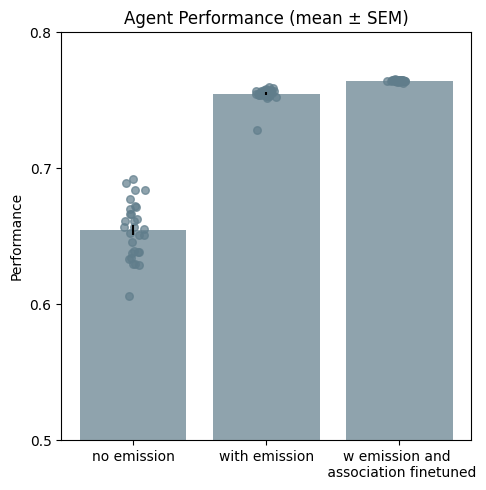

[0.6546773748201627, 0.7547697500703235, 0.7644372085077067]


In [ ]:
import matplotlib.pyplot as plt
import numpy as np

means = [
    np.mean(performances_wo_emission),
    np.mean(performances_w_emission),
    np.mean(performances_w_emissiontrained)
]
sems = [
    np.std(performances_wo_emission)/np.sqrt(len(performances_wo_emission)), 
    np.std(performances_w_emission)/np.sqrt(len(performances_w_emission)),
    np.std(performances_w_emissiontrained)/np.sqrt(len(performances_w_emissiontrained))
]

x_pos = np.arange(len(means))
labels = ['no emission', 'with emission', 'w emission and \n association finetuned']
colors = ['#607D8B', '#607D8B', '#607D8B']

fig, ax = plt.subplots(figsize=(5, 5))
bars = ax.bar(x_pos, means, yerr=sems, capsize=0, alpha=0.7, color=colors)

# add scatter points for individual performances
perf_vectors = [performances_wo_emission, performances_w_emission, performances_w_emissiontrained]
for i, perf_vec in enumerate(perf_vectors):
    # jitter x a little to avoid totally overlapping points
    x_vals = np.random.normal(loc=x_pos[i], scale=0.04, size=len(perf_vec))
    ax.scatter(x_vals, perf_vec, alpha=0.7, s=30, color=colors[i])

ax.set_ylabel('Performance')
ax.set_xticks(x_pos)
ax.set_xticklabels(labels)
ax.set_ylim(0.5, 0.7)
ax.set_yticks([0.5, 0.6, 0.7, 0.8])
ax.set_title('Agent Performance (mean ± SEM)')

plt.tight_layout()
#plt.savefig('figures/WP_performance_with_probabilistic_mars2026.pdf')
plt.show()
print(means)

In [ ]:
import pickle
[all_map_particles, prediction_weather, polarity_particles, performances_optimal_] = pickle.load(open('results/performances_optimal.pkl', 'rb'))

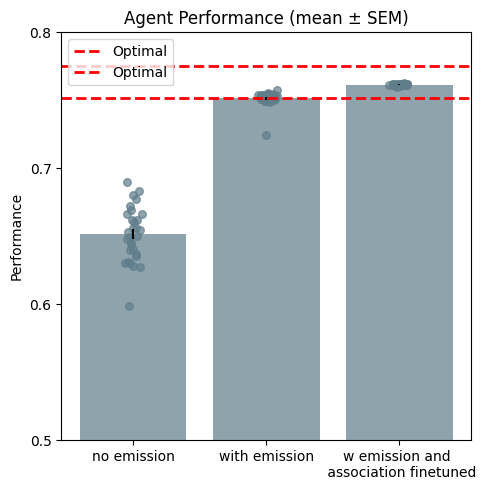

[0.6514835665661594, 0.7515402000857393, 0.7615287002521752]


In [ ]:
import matplotlib.pyplot as plt
import numpy as np

means = [
    np.mean(performances_wo_emission),
    np.mean(performances_w_emission),
    np.mean(performances_w_emissiontrained)
]
sems = [
    np.std(performances_wo_emission)/np.sqrt(len(performances_wo_emission)), 
    np.std(performances_w_emission)/np.sqrt(len(performances_w_emission)),
    np.std(performances_w_emissiontrained)/np.sqrt(len(performances_w_emissiontrained))
]

x_pos = np.arange(len(means))
labels = ['no emission', 'with emission', 'w emission and \n association finetuned']
colors = ['#607D8B', '#607D8B', '#607D8B']

fig, ax = plt.subplots(figsize=(5, 5))
bars = ax.bar(x_pos, means, yerr=sems, capsize=0, alpha=0.7, color=colors)

# add scatter points for individual performances
perf_vectors = [performances_wo_emission, performances_w_emission, performances_w_emissiontrained]
for i, perf_vec in enumerate(perf_vectors):
    # jitter x a little to avoid totally overlapping points
    x_vals = np.random.normal(loc=x_pos[i], scale=0.04, size=len(perf_vec))
    ax.scatter(x_vals, perf_vec, alpha=0.7, s=30, color=colors[i])

# Add optimal performance reference as a dashed vertical line
optimal_mean = performances_optimal_.mean()
ax.axhline(optimal_mean, color='r', linestyle='--', linewidth=2, label="Optimal")
ax.legend()

ax.set_ylabel('Performance')
ax.set_xticks(x_pos)
ax.set_xticklabels(labels)
ax.set_ylim(0.5, 0.7)
ax.set_yticks([0.5, 0.6, 0.7, 0.8])
ax.set_title('Agent Performance (mean ± SEM)')

plt.tight_layout()
plt.savefig('figures/WP_performance_with_probabilistic_april2026.pdf')
plt.show()
print(means)

# # With probabilistic feedbacks and previously learned probability function and finetuned

In [ ]:
# performances as a function of the sequence length
nb_agents = 30
nb_simuls = 100
association_probs = np.zeros((nb_agents, nb_simuls, 500, 4))
chosen_correct = np.zeros((nb_agents, nb_simuls, 500))
association_probs_reversals = np.zeros((nb_agents, nb_simuls, 500, 4))
ground_truth_probas_reversals = np.zeros((nb_agents, nb_simuls, 500, 4))
chosen_correct_reversals = np.zeros((nb_agents, nb_simuls, 500))
itrial = 300

for idx_agent in range(nb_agents):
    """
    self = Worker(
        probabilistic_task(),
        "results/source/saved_models",
        "WP_GRU_associationFinetunedOnly_agent{0}".format(idx_agent),
        w_emission=True,
        train_w_emission=True,
        train_in_cat_task_from_scratch=False,
    )
    """
    self = Worker(
        probabilistic_task(),
        "results/source/saved_models",
        "WP_GRU_agent{0}".format(idx_agent),
        w_emission=True,
        train_w_emission=True,
        train_in_cat_task_from_scratch=False,
        entropy_reg=None,
        associationFinetunedOnly=False,
    )

    self.load_model(nb_episodes=50000)

    # generate data
    np.random.seed(idx_agent)
    self.env.generate_test_task(num_tasks=nb_simuls, num_trials=500, num_steps=5, probas=None, variable_length=False, tau=0.0)
    initial_probas = self.env.probas.copy()
    env_probas = np.zeros([nb_simuls, 500, 4])
    for i in range(nb_simuls):
        np.random.seed(i)
        env_probas[i] = self.env.probas[i, 0]
        while True:
            if (env_probas[i, 0] != env_probas[i, -1]).any():
                break
            env_probas[i, itrial:] = env_probas[i, 0][np.random.choice(np.arange(4), replace=False, size=4)]

    np.random.seed(idx_agent)
    self.env.generate_test_task(num_tasks=nb_simuls, num_trials=500, num_steps=5, probas=env_probas, variable_length=False)
    result1 = self.evaluate()
    chosen_correct_reversals[idx_agent] = (result1['logpredicts'].argmax(-1) == self.env.correct_weather).float().numpy()

    # psychometric curve
    np.random.seed(idx_agent)
    self.env.generate_test_task(num_tasks=nb_simuls, num_trials=500, num_steps=5, probas=initial_probas, variable_length=False, tau=0.0)
    result2 = self.evaluate()
    index_sorted = np.argsort(np.unique(self.env.probas, axis=1).squeeze(), axis=1)
    association_probs[idx_agent] = np.swapaxes(result2['probas_association'][np.arange(nb_simuls)[:, None],: , index_sorted].detach().numpy(), 1, 2)
    chosen_correct[idx_agent] = (result2['logpredicts'].argmax(-1) == self.env.correct_weather).float().numpy()

    # example of a reversal
    env_probas = np.zeros([nb_simuls, 500, 4])
    indexes_sorted = np.zeros([nb_simuls, 4], dtype=int)
    for i in range(nb_simuls):
        np.random.seed(i)
        probas_0 = np.round(self.env.probas[:, 0][i], 1)
        env_probas[i, :itrial] = probas_0
        probas_0_after_reversal = probas_0.copy()
        probas_0_after_reversal[probas_0 == 0.4] = 0.6
        probas_0_after_reversal[probas_0 == 0.6] = 0.8
        probas_0_after_reversal[probas_0 == 0.8] = 0.4
        env_probas[i, itrial:] = probas_0_after_reversal
        indexes_sorted[i] = index_sorted[i]

    self.env.probas = env_probas
    np.random.seed(idx_agent)
    self.env.generate_test_task(num_tasks=nb_simuls, num_trials=500, num_steps=5, probas=self.env.probas, variable_length=False)

    result1 = self.evaluate()
    association_probs_reversals[idx_agent] = np.swapaxes(result1['probas_association'][np.arange(nb_simuls)[:, None], :, indexes_sorted].detach().numpy(), 1, 2)
    ground_truth_probas_reversals[idx_agent] = np.swapaxes(result1['true_association_probas'][np.arange(nb_simuls)[:, None], :, indexes_sorted], 1, 2)

association_probs_reversals = np.mean(association_probs_reversals, axis=1)
ground_truth_probas_reversals = np.mean(ground_truth_probas_reversals, axis=1)
chosen_correct_reversals = np.mean(chosen_correct_reversals, axis=1)

association_probs = np.mean(association_probs, axis=1)
chosen_correct = np.mean(chosen_correct, axis=1)

loaded the emission model with 50000 iterations
loading model results/source/saved_models/WP_GRU_agent0_init_xavier_optim_Adam_episodeNbMax_50000_numUnits_32_trainWithEmission_False_trainInCatTaskFromScratch_False/model-50000.pth
loaded W_output_association
key W_output_emission not found in state_dict
loaded gru_association.weight_ih_l0
loaded gru_association.weight_hh_l0
loaded gru_association.bias_ih_l0
loaded gru_association.bias_hh_l0
key gru_emission.weight_ih_l0 not found in state_dict
key gru_emission.weight_hh_l0 not found in state_dict
key gru_emission.bias_ih_l0 not found in state_dict
key gru_emission.bias_hh_l0 not found in state_dict
loaded the association model
loading model results/source/saved_models/WP_GRU_agent0_init_xavier_optim_Adam_episodeNbMax_50000_numUnits_32_trainWithEmission_True_trainInCatTaskFromScratch_False/model-50000.pth
loaded W_output_association
loaded W_output_emission
loaded gru_association.weight_ih_l0
loaded gru_association.weight_hh_l0
loaded gr

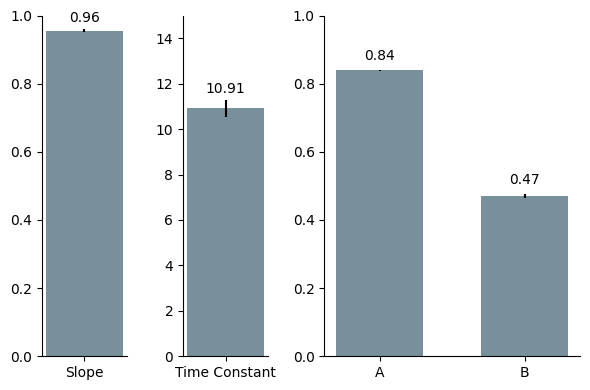

In [ ]:
from scipy.optimize import curve_fit
import numpy as np
import matplotlib.pyplot as plt

# Define the exponential recovery function
def exp_func(t, A, B, tau):
    return A + (B - A) * np.exp(-t / tau)

# Fit reversal parameters (A, B, tau) for each agent
reversal_params = np.zeros((len(chosen_correct_reversals), 3))
reversal_predictions = np.zeros((len(chosen_correct_reversals), 199))
for i, chosen_ in enumerate(chosen_correct_reversals):
    y = chosen_[301:]
    t = np.arange(y.size)
    popt, pcov = curve_fit(exp_func, t, y, p0=[y[-1], y[0], 20])
    reversal_params[i] = popt  # [A, B, tau]
    reversal_predictions[i] = exp_func(t, *popt)
# Fit a slope for the psychometric curve for each agent
from sklearn.linear_model import LinearRegression
slopes = np.zeros(len(association_probs[:, -1]))
intercepts = np.zeros(len(association_probs[:, -1]))
for i, asso in enumerate(association_probs[:, -1]):
    lr = LinearRegression()
    X = np.array([0.2, 0.4, 0.6, 0.8]).reshape(-1, 1)
    y = asso
    lr.fit(X, y)
    slopes[i] = lr.coef_[0]
    intercepts[i] = lr.intercept_

n_agents = len(slopes)

color_all = "#607D8B"
color_A = "#607D8B"
color_B = "#A6A6A6"

# Create a gridspec so that the last subplot is twice as big as the first two
from matplotlib import gridspec
fig = plt.figure(figsize=(6, 4))
gs = gridspec.GridSpec(1, 3, width_ratios=[1, 1, 3])
axs = [fig.add_subplot(gs[0, i]) for i in range(3)]

# Plot 1: Slope Bar Plot
ax1 = axs[0]
mean_slope = np.mean(slopes)
sem_slope = np.std(slopes, ddof=1) / np.sqrt(n_agents)
bar1 = ax1.bar([0], [mean_slope], yerr=[sem_slope], color=color_all, capsize=0, alpha=0.85, width=0.7)
ax1.text(0, mean_slope + sem_slope + 0.01, f"{mean_slope:.2f}", ha='center', va='bottom', fontsize=10)
ax1.set_xticks([0])
ax1.set_xticklabels(["Slope"])
ax1.set_ylim([0, 1])
ax1.spines['right'].set_visible(False)
ax1.spines['top'].set_visible(False)

# Plot 2: Tau Bar Plot
ax2 = axs[1]
tau_vals = reversal_params[:,2]
mean_tau = np.mean(tau_vals)
sem_tau = np.std(tau_vals, ddof=1) / np.sqrt(n_agents)
bar2 = ax2.bar([0], [mean_tau], yerr=[sem_tau], color=color_all, capsize=0, alpha=0.85, width=0.7)
ax2.text(0, mean_tau + sem_tau + 0.2, f"{mean_tau:.2f}", ha='center', va='bottom', fontsize=10)
ax2.set_xticks([0])
ax2.set_xticklabels(["Time Constant"])
ax2.set_ylim([0, 15])
ax2.spines['right'].set_visible(False)
ax2.spines['top'].set_visible(False)

# Plot 3: Asymptote (A) and Initial (B) on the same plot
ax3 = axs[2]
A_vals = reversal_params[:,0]
B_vals = reversal_params[:,1]
mean_A = np.mean(A_vals)
sem_A = np.std(A_vals, ddof=1) / np.sqrt(n_agents)
mean_B = np.mean(B_vals)
sem_B = np.std(B_vals, ddof=1) / np.sqrt(n_agents)
width = 0.6

ax3.bar([0], [mean_A], yerr=[sem_A], color=color_A, capsize=0, alpha=0.85, width=width, label="Asymptote (A)")
ax3.bar([1], [mean_B], yerr=[sem_B], color=color_A, capsize=0, alpha=0.85, width=width, label="Initial (B)")
ax3.text(0, mean_A + sem_A + 0.02, f"{mean_A:.2f}", ha='center', va='bottom', fontsize=10)
ax3.text(1, mean_B + sem_B + 0.02, f"{mean_B:.2f}", ha='center', va='bottom', fontsize=10)
ax3.set_xticks([0, 1])
ax3.set_xticklabels(["A", "B"])
ax3.set_ylim(0, 1)
ax3.spines['right'].set_visible(False)
ax3.spines['top'].set_visible(False)

plt.tight_layout()
plt.savefig('figures/WP_reversal_w_finetuned_april2026_params.pdf')
plt.show()


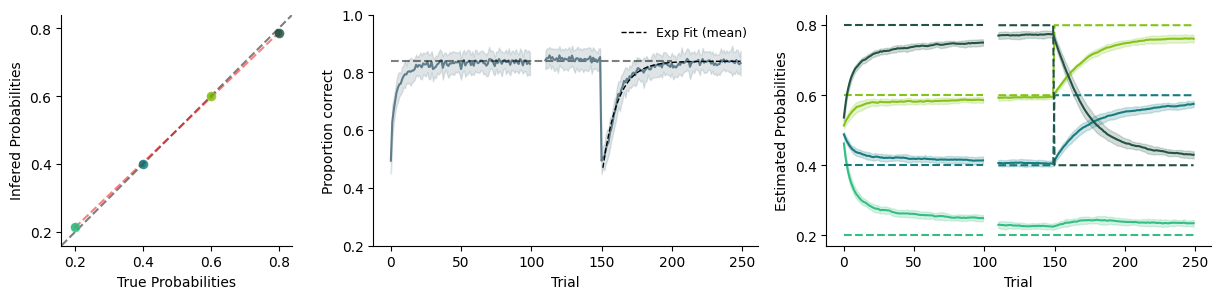

In [ ]:
soothing_greens =  ["#34BE82", "#167C80", "#84C318", "#235345"]

fig, axs = plt.subplots(1, 3, figsize=(15, 3), gridspec_kw={'width_ratios': [2, 3, 3]})
pmeans = association_probs[:, -1].mean(axis=0)
pstds = association_probs[:, -1].std(axis=0)
axs[0].scatter(np.array([0.2, 0.4, 0.6, 0.8]), pmeans, alpha=0.7, color=soothing_greens, s=20)
for i, color in enumerate(soothing_greens):
    axs[0].errorbar(np.array([0.2, 0.4, 0.6, 0.8])[i], pmeans[i], yerr=pstds[i], alpha=0.7, color=color, fmt='o')
axs[0].plot([0, 1], [0, 1], 'k--', alpha=0.5, label='x=y')
axs[0].set_ylabel('Infered Probabilities')
axs[0].set_xlabel('True Probabilities')
axs[0].set_xlim(0.16, 0.84)
axs[0].set_xticks([0.2, 0.4, 0.6, 0.8])
axs[0].set_ylim(0.16, 0.84)
axs[0].set_yticks([0.2, 0.4, 0.6, 0.8])
axs[0].set_aspect('equal', adjustable='box')
axs[0].spines['right'].set_visible(False)
axs[0].spines['top'].set_visible(False)
axs[0].plot([0.2, 0.4, 0.6, 0.8], slopes.mean() * np.array([0.2, 0.4, 0.6, 0.8]) + intercepts.mean(), 'r--', alpha=0.5)

# reversal plots of beliefs
mean_correct = chosen_correct.mean(axis=0)
std_correct = chosen_correct.std(axis=0)
mean_correct_reversals = chosen_correct_reversals.mean(axis=0)
std_correct_reversals = chosen_correct_reversals.std(axis=0)
xx = np.arange(110, 250)
pmean_correct = mean_correct[:100]
pstd = std_correct[:100]
light_grey = "#607D8B"
axs[1].plot(pmean_correct, color=light_grey)
axs[1].plot( [0, 200], [mean_A, mean_A], 'k--', alpha=0.5)
axs[1].fill_between(np.arange(100), pmean_correct - pstd, pmean_correct + pstd, alpha=0.2, color=light_grey)
axs[1].set_ylabel('Proportion correct')
axs[1].set_xlabel('Trial')
axs[1].plot(xx, mean_correct_reversals[260:400], color=light_grey)
axs[1].fill_between(xx, mean_correct_reversals[260:400] - std_correct_reversals[260:400], mean_correct_reversals[260:400] + std_correct_reversals[260:400], alpha=0.2, color=light_grey)
axs[1].set_xticks([0, 50, 100, 150, 200, 250])
axs[1].set_ylim(0.2, 1.)
axs[1].set_yticks([0.2, 0.4, 0.6, 0.8, 1.0])
axs[1].spines['right'].set_visible(False)
axs[1].spines['top'].set_visible(False)

# Plot mean fitted exponential after reversal for the black mean
# Use exp_func(t, A, B, tau) and mean_B, mean_A, mean_tau from previous fit
if 'mean_A' in locals() and 'mean_B' in locals() and 'mean_tau' in locals():
    t_fit = np.arange(151, 250)
    exp_curve = exp_func(t_fit - 151, mean_A, mean_B, mean_tau)
    axs[1].plot(t_fit, exp_curve[:len(t_fit)], "--", color='black', linewidth=1, label='Exp Fit (mean)')
    axs[1].legend(frameon=False, fontsize=9, loc='upper right')

# reversal plots of beliefs
mean_association_probs_reversals = association_probs_reversals.mean(axis=0)
std_association_probs_reversals = association_probs_reversals.std(axis=0)
mean_ground_truth_probas_reversals = ground_truth_probas_reversals.mean(axis=0)
xx = np.arange(110, 250)
for i in range(4):
    pmean = association_probs.mean(axis=0)[:100, i]
    pstd = association_probs.std(axis=0)[:100, i]
    axs[2].plot(pmean, color=soothing_greens[i])
    axs[2].fill_between(np.arange(100), pmean - pstd, pmean + pstd, alpha=0.2, color=soothing_greens[i])
    p = np.array([0.2, 0.4, 0.6, 0.8])[i]
    axs[2].plot(p * np.ones(100), linestyle='--', color=soothing_greens[i])
axs[2].set_ylabel('Estimated Probabilities')
axs[2].set_xlabel('Trial')
for i in range(4):
    axs[2].plot(xx, mean_association_probs_reversals[260:400, i], color=soothing_greens[i])
    axs[2].plot(xx, mean_ground_truth_probas_reversals[260:400, i], linestyle='--', color=soothing_greens[i])
    axs[2].fill_between(xx, 
                        mean_association_probs_reversals[260:400, i] - std_association_probs_reversals[260:400, i], 
                        mean_association_probs_reversals[260:400, i] + std_association_probs_reversals[260:400, i], 
                        alpha=0.2, color=soothing_greens[i])
    axs[2].set_xticks([0, 50, 100, 150, 200, 250])
axs[2].set_ylim(0.17, 0.83)
axs[2].set_yticks([0.2, 0.4, 0.6, 0.8])
axs[2].spines['right'].set_visible(False)
axs[2].spines['top'].set_visible(False)
plt.savefig('figures/WP_reversal_w_finetuned_april2026.pdf')

plt.show()